# Построение модели линейной регрессии

In [49]:
import torch
import numpy as np
import matplotlib.pyplot as plt

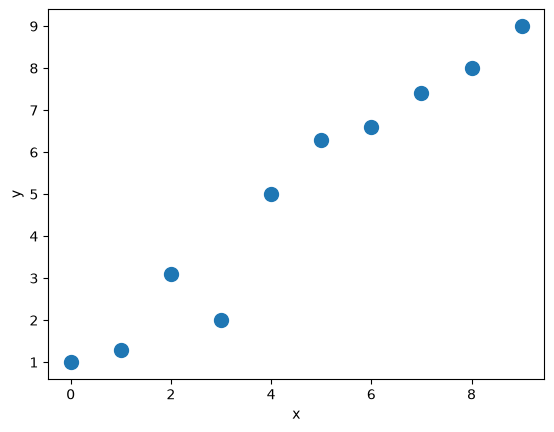

In [50]:
X_train = np.arange(10, dtype='float32').reshape((10,1))
y_train = np.array([1.0, 1.3, 3.1, 2.0, 5.0, 
                    6.3, 6.6, 7.4, 8.0, 9.0], dtype='float32')
plt.plot(X_train, y_train, 'o', markersize=10) 
plt.xlabel('x')
plt.ylabel('y') 
plt.show()

In [51]:
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader

X_train_norm = (X_train - np.mean(X_train)) / np.std(X_train) 
X_train_norm = torch.from_numpy(X_train_norm) 
y_train_ten = torch.from_numpy(y_train).float()
train_ds = TensorDataset(X_train_norm, y_train_ten)
batch_size = 1
train_dl = DataLoader(train_ds, batch_size, shuffle=True)

In [52]:
torch.manual_seed(1)
weight = torch.randn(1, requires_grad=True)
bias = torch.zeros(1, requires_grad=True) 
def model(xb):
    return xb @ weight + bias

def loss_fn(input, target):
    return (input - target).pow(2).mean()

In [53]:
learning_rate = 0.001
num_epochs = 200
log_epochs = 10 
for epoch in range(num_epochs):
    for x_batch, y_batch in train_dl:
        pred = model(x_batch)
        loss = loss_fn(pred, y_batch.long()) 
        loss.backward() 
        with torch.no_grad():
            weight -= weight.grad * learning_rate
            bias -= bias.grad * learning_rate
            weight.grad.zero_()
            bias.grad.zero_()
    if epoch % log_epochs==0:
        print(f'Эпoxa {epoch} Потеря {loss.item():.4f}')


Эпoxa 0 Потеря 39.8977
Эпoxa 10 Потеря 23.7719
Эпoxa 20 Потеря 1.0158
Эпoxa 30 Потеря 14.8444
Эпoxa 40 Потеря 12.4277
Эпoxa 50 Потеря 4.9904
Эпoxa 60 Потеря 0.7894
Эпoxa 70 Потеря 3.7337
Эпoxa 80 Потеря 2.3939
Эпoxa 90 Потеря 0.4472
Эпoxa 100 Потеря 1.1216
Эпoxa 110 Потеря 1.3220
Эпoxa 120 Потеря 0.1076
Эпoxa 130 Потеря 0.5718
Эпoxa 140 Потеря 0.2256
Эпoxa 150 Потеря 1.4922
Эпoxa 160 Потеря 0.0495
Эпoxa 170 Потеря 0.0064
Эпoxa 180 Потеря 0.0017
Эпoxa 190 Потеря 0.0305


Окончательные параметры: 2.644019603729248 4.712854862213135


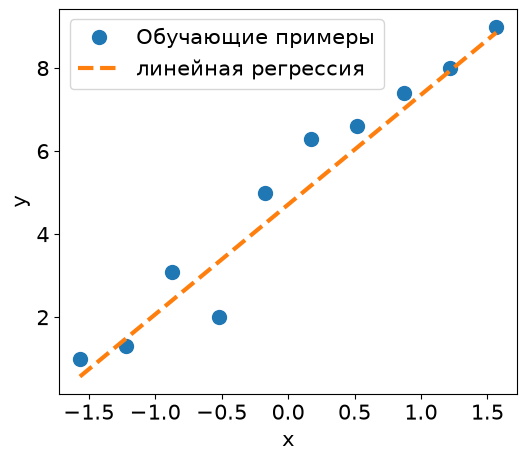

In [54]:
print ('Окончательные параметры:', weight.item(), bias.item()) 
X_test = np.linspace(0, 9, num=100, dtype='float32').reshape(-1, 1)
X_test_norm = (X_test - np.mean(X_train)) / np.std(X_train)
X_test_norm = torch.from_numpy(X_test_norm) 
y_pred = model(X_test_norm).detach().numpy() 
fig = plt.figure(figsize=(13, 5))
ax= fig.add_subplot(1, 2, 1)
plt.plot(X_train_norm, y_train, 'o', markersize=10)
plt.plot(X_test_norm, y_pred, '--', lw=3) 
plt.legend(['Обучающие примеры', 'линейная регрессия'], fontsize=15)
ax.set_xlabel('x', size=15)
ax.set_ylabel('y', size=15)
ax.tick_params(axis='both', which='major', labelsize=15) 
plt.show() 

### Обучение модели с помощью модулей torch.nn и torch.optim 

In [56]:
import torch.nn as nn

loss_fb = nn.MSELoss(reduction='mean')
input_size = 1
output_size = 1

model = nn.Linear(input_size, output_size)
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

In [ ]:
for epoch in range(num_epochs):
    for x_batch, y_batch in train_dl:
        # Генерируем прогнозы
        pred = model(x_batch)[:, 0] 
        # Вычисляем потери
        loss = loss_fn(pred, y_batch)
        # Вычисляем градиенты
        loss.backward()
        # Обновляем параметры, используя градиенты
        optimizer.step()
        # Обнуляем градиенты
        optimizer.zero_grad() 
    if epoch % log_epochs==0:
        print(f'Эпохи {epoch} Потери {loss.item():.4f}')


Эпохи 0 Потери 17.3596
Эпохи 10 Потери 0.5473
Эпохи 20 Потери 8.7409
Эпохи 30 Потери 0.1664
Эпохи 40 Потери 1.8662
Эпохи 50 Потери 0.2789
Эпохи 60 Потери 0.5117
Эпохи 70 Потери 0.9404
Эпохи 80 Потери 0.0227
Эпохи 90 Потери 1.2027
Эпохи 100 Потери 0.0501
Эпохи 110 Потери 0.0906
Эпохи 120 Потери 0.0746
Эпохи 130 Потери 0.4006
Эпохи 140 Потери 0.2038
Эпохи 150 Потери 0.4675
Эпохи 160 Потери 0.1890
Эпохи 170 Потери 0.1132
Эпохи 180 Потери 0.1179
Эпохи 190 Потери 0.0776


In [ ]:
print('Окончательные параметры: ', model.weight.item() ,model.bias.item()) 

Окончательные параметры:  2.6615240573883057 4.8941874504089355
